# Passo 5 — Teste de Hipótese (Python)

**Hipótese:** "A duração média das corridas do Loop ao Aeroporto O'Hare muda nos sábados chuvosos."

**Arquivo utilizado:**
- `moved_project_sql_result_07.csv` → corridas Loop → O'Hare em sábados, com condições climáticas e duração

## Etapas

**Etapa 1** — Importação das bibliotecas

**Etapa 2** — Importar o CSV e verificar os dados

**Etapa 3** — Definir nível de significância (alfa) e formular H0 e H1

**Etapa 4** — Separar os grupos: corridas em dias "Bad" e "Good"

**Etapa 5** — Escolher e justificar o teste estatístico

**Etapa 6** — Executar o teste

**Etapa 7** — Interpretar o resultado e escrever conclusão

In [1]:
# Etapa 1: Importação das bibliotecas
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
# Etapa 2: Importar o CSV e verificar os dados
data7 = pd.read_csv('../data/moved_project_sql_result_07.csv')
data7['start_ts'] = pd.to_datetime(data7['start_ts'])  # corrigindo tipo para datetime
print(data7.info())
print()
print(data7.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB
None

             start_ts weather_conditions  duration_seconds
0 2017-11-25 16:00:00               Good            2410.0
1 2017-11-25 14:00:00               Good            1920.0
2 2017-11-25 12:00:00               Good            1543.0
3 2017-11-04 10:00:00               Good            2512.0
4 2017-11-11 07:00:00               Good            1440.0


## Etapa 3 — Hipóteses e nível de significância

**Nível de significância (alfa):** Vou usar o padrão de 0.05

**H0 (hipótese nula):** Tendo em mente a hipótese em questão, a nula seria que a duração média das corridas em dias de mau tempo ("Bad") é igual à duração média em dias de bom tempo ("Good") — ou seja, o clima não afeta a duração.

**H1 (hipótese alternativa):** Já em contrapartida, a alternativa seria que a duração média das corridas em dias de mau tempo ("Bad") é diferente da duração em dias de bom tempo ("Good") — ou seja, o clima afeta a duração.

In [3]:
# Etapa 4: Separar os grupos Bad e Good
bad = data7[data7['weather_conditions'] == 'Bad']['duration_seconds']
good = data7[data7['weather_conditions'] == 'Good']['duration_seconds']

print("Número de amostras 'Bad':", len(bad))
print()
print("Número de amostras 'Good':", len(good))

Número de amostras 'Bad': 180

Número de amostras 'Good': 888


## Etapa 5 — Escolha e justificativa do teste estatístico

Vou escolher o teste t de Student para amostras independentes, pois o objetivo é comparar as médias de duração entre dois grupos independentes (Bad e Good). As amostras são suficientemente grandes e de tamanhos diferentes, e o teste t é robusto para este caso.

Após verificar as variâncias das amostras (`bad.var()` = 520.294 e `good.var()` = 576.382), constatei que são diferentes — portanto utilizei `equal_var=False`, que aplica o **Teste de Welch**, variante do teste t mais adequada quando as variâncias dos grupos são desiguais, pois ajusta os graus de liberdade e garante um resultado estatisticamente mais confiável.

<Figure size 800x600 with 0 Axes>

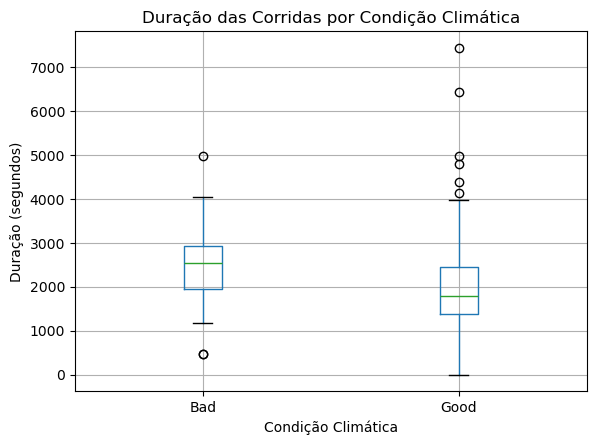

Variância Bad: 520294.08600248274
Variância Good: 576382.0096895089
Variâncias iguais: False
Estatística t: 7.186034288068629
p-value: 6.738994326108735e-12
Rejeitamos a hipótese nula: há uma diferença significativa entre os grupos 'Bad' e 'Good'


In [4]:
# Etapa 6: Executar o teste e visualizar

# Boxplot para visualizar a distribuição dos dados
plt.figure(figsize=(8, 6))
data7.boxplot(column='duration_seconds', by='weather_conditions')
plt.title('Duração das Corridas por Condição Climática')
plt.suptitle('')
plt.xlabel('Condição Climática')
plt.ylabel('Duração (segundos)')
plt.show()

# Verificar se as variâncias são iguais
print('Variância Bad:', bad.var())
print('Variância Good:', good.var())
print('Variâncias iguais:', bad.var() == good.var())

# Teste de Welch — equal_var=False pois as variâncias são diferentes
stat, p_value = stats.ttest_ind(bad, good, equal_var=False)
print('Estatística t:', stat)
print('p-value:', p_value)

if p_value < 0.05:
    print("Rejeitamos a hipótese nula: há uma diferença significativa entre os grupos 'Bad' e 'Good'")
else:
    print("Não rejeitamos a hipótese nula: não há uma diferença significativa entre os grupos 'Bad' e 'Good'")

## Etapa 7 — Conclusão

### Resultado do Teste Estatístico

Antes de executar o teste, verifiquei as variâncias das amostras:
- **Variância Bad:** 520.294 | **Variância Good:** 576.382 → variâncias **diferentes**

Por isso utilizei `equal_var=False`, que aplica o **Teste de Welch** — variante do teste t mais adequada quando as variâncias dos grupos são desiguais, pois ajusta os graus de liberdade e garante um resultado estatisticamente mais confiável.

- **p-value = 6.74e-12** → extremamente menor que alfa (0.05)
- **Conclusão: rejeito H0**

Há evidência estatística forte de que o clima afeta a duração das corridas do Loop ao O'Hare nos sábados. A hipótese alternativa (H1) é confirmada.

---

### Análise Visual — Boxplot

**1. Tendência Central (Mediana)**
A mediana é visivelmente mais alta em dias de clima ruim (Bad) — ultrapassa 2500 segundos, enquanto em dias Good fica abaixo de 2000 segundos.

**2. Dispersão e Variabilidade**
A caixa de Bad está em um patamar superior e mais concentrado. A caixa de Good é mais ampla, indicando maior variação na duração, mas com a maioria das corridas mais rápidas.

**3. Outliers**
Ambos os grupos apresentam outliers. Em Good, chegam a ultrapassar 7000 segundos — possivelmente engarrafamentos ou eventos excepcionais em dias de trânsito teoricamente fluido.

---

### Conclusão Prática para a Zuber

O clima é uma variável relevante para a operação. Em sábados chuvosos, as corridas do Loop ao O'Hare duram significativamente mais, o que impacta diretamente o planejamento de frotas, estimativa de tempo de chegada e precificação dinâmica. Considerar a condição climática como fator preditivo pode melhorar a experiência do passageiro e a eficiência operacional da empresa.